In [ ]:
#Conexión con Google Drive para trabajar con los archivos almacenados
from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: 

In [ ]:
# ---------------------------
#Importaciones iniciales
# ---------------------------
import torch
from torch.optim import AdamW
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from transformers import BertTokenizerFast, BertModel, get_scheduler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import nltk
import os
nltk.download('punkt')
import joblib


# 1. Cargar datos
# ---------------------------
df = pd.read_json("/content/drive/MyDrive/Titulacion/DatasetsFinales/df_train2_featselect2.jsonl", lines=True)
#df= df.head(30)
X = df.drop('label', axis=1)
y = df['label']


# ---------------------------
# 2. Preprocesamiento de características
# ---------------------------
# TF-IDF
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(X['transcription_processed']).toarray()
X_tfidf_df = pd.DataFrame(X_tfidf)


# Características adicionales
X_features = X.iloc[:, 3:]
X_features = X_features.fillna(X_features.mean())


# Unir TF-IDF + Características
combined_df = pd.concat([X_tfidf_df, X_features], axis=1)

combined_df.columns = combined_df.columns.astype(str)
scaler = MinMaxScaler()
normalized_df = scaler.fit_transform(combined_df)
normalized_tensor = torch.tensor(normalized_df, dtype=torch.float32)
labels_tensor = torch.tensor(y.values, dtype=torch.long)


# ---------------------------
# 3. Tokenización con BERT (ahora usando el modelo español)
# ---------------------------
model_name = "dccuchile/bert-base-spanish-wwm-cased"  # Cambiado al modelo español
tokenizer = BertTokenizerFast.from_pretrained(model_name)
max_length = 64

encodings = tokenizer(X['transcription_processed'].tolist(),
                      padding=True, truncation=True,
                      max_length=max_length, return_tensors="pt")


# Dataset final
dataset = TensorDataset(encodings['input_ids'], encodings['attention_mask'], normalized_tensor, labels_tensor)


# ---------------------------
# 4. Dividir en entrenamiento y validación
# ---------------------------

train_size = int(0.8 * len(dataset))
train_dataset, val_dataset = random_split(dataset, [train_size, len(dataset) - train_size])
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16)


# ---------------------------
# 5. Definir Modelo-------------------------------------------
# ---------------------------

class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_extra_features):
        super().__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)#
        self.fc1 = nn.Linear(bert_model.config.hidden_size + num_extra_features, 256)
        self.relu = nn.ReLU()#
        self.fc2 = nn.Linear(256, 2)#
        self.softmax = nn.LogSoftmax(dim=1)#

    def forward(self, input_ids, attention_mask, extra_features):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]#salidas finales e informacion del cls
        x = torch.cat((cls_output, extra_features), dim=1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.softmax(self.fc2(x))


# ---------------------------
# 6. Entrenamiento con Early Stopping (Basado en pérdida de validación)-----------------------------------------
# ---------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert = BertModel.from_pretrained(model_name)  # Ahora carga el modelo español
model = BertClassifier(bert, normalized_tensor.shape[1]).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)


# Número máximo de épocas (suficientemente alto para permitir Early Stopping)
max_epochs = 100


# Parámetros de Early Stopping
patience = 3  # Número de épocas sin mejora (disminución de la pérdida de validación) antes de detener

scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=len(train_dataloader) * max_epochs)


# Calcular pesos de clases
train_labels = [label.item() for _, _, _, label in train_dataset]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
loss_fn = nn.NLLLoss(weight=weights_tensor)

def train_epoch():
    model.train()
    total_loss = 0
    for batch in tqdm(train_dataloader):
        input_ids, attention_mask, features, labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, features)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(train_dataloader)

def evaluate():
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in val_dataloader:
            input_ids, attention_mask, features, labels = [b.to(device) for b in batch]
            outputs = model(input_ids, attention_mask, features)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            preds = torch.argmax(outputs, axis=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss = total_loss / len(val_dataloader)

    # Calculate metrics (Mantener estas métricas es útil para monitorear el rendimiento)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    accuracy = accuracy_score(all_labels, all_preds)

  # Devolver la pérdida de validación y las métricas
  return val_loss, macro_f1, precision, recall, accuracy


# ---------------------------
# 7. Ejecutar entrenamiento con Early Stopping (Basado en pérdida de validación)
# ---------------------------

best_val_loss = float('inf') # Inicializar con infinito positivo para buscar el mínimo
epochs_without_improvement = 0

metrics_history = [] # Para almacenar las métricas de cada época

save_path = "/content/drive/MyDrive/Titulacion/Entrenamiento/Transfomer/bert-base-spanish/"
model_save_path = "/content/drive/MyDrive/Titulacion/Entrenamiento/Transfomer/bert-base-spanish/caracteristicas/"

# Asegurarse de que el directorio existe
os.makedirs(model_save_path, exist_ok=True)
for epoch in range(max_epochs):
    print(f"\nEpoch {epoch + 1}/{max_epochs}")
    train_loss = train_epoch()
    print(f"Train Loss: {train_loss:.4f}")

    # Obtener la pérdida de validación y las métricas
    val_loss, macro_f1, precision, recall, accuracy = evaluate()
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Macro F1: {macro_f1:.4f}")
    #print(f"Precision: {precision:.4f}")
    #print(f"Recall: {recall:.4f}")
    #print(f"Accuracy: {accuracy:.4f}")


    # Almacenar las métricas para esta época
    metrics_history.append({
        'Epoch': epoch + 1,
        'Train Loss': train_loss,
        'Validation Loss': val_loss,
        'Macro F1': macro_f1,
        'Precision': precision,
        'Recall': recall,
        'Accuracy': accuracy
    })


    # Lógica de Early Stopping basada en la pérdida de validación
    if val_loss < best_val_loss: # Si la pérdida de validación mejora (disminuye)
        best_val_loss = val_loss
        epochs_without_improvement = 0

        # Opcional: Guardar el mejor modelo (basado en la menor pérdida de validación)
        torch.save(model, save_path + 'best_model_spanish_loss.pt') # Nombre de archivo diferente para distinguirlo

        # Guardar el vectorizer
        joblib.dump(vectorizer, model_save_path + 'tfidf_vectorizer.pkl')
        print(f"Vectorizer guardado en: {model_save_path + 'tfidf_vectorizer.pkl'}")

        # Guardar el scaler
        joblib.dump(scaler, model_save_path + 'minmax_scaler.pkl')
        print(f"Scaler guardado en: {model_save_path + 'minmax_scaler.pkl'}")

        # Guardar el tokenizer
        tokenizer.save_pretrained(model_save_path + 'tokenizer_files/')
        print(f"Tokenizer guardado en: {model_save_path + 'tokenizer_files/'}")
        feature_columns = X_features.columns.tolist()
        joblib.dump(feature_columns, model_save_path + 'feature_columns.pkl')

    else: # Si la pérdida de validación no mejora
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping después de {patience} épocas sin mejora en la pérdida de validación.")
            break # Detiene el entrenamiento


# Mostrar la tabla de métricas al final
print("\nMétricas por Época:")
metrics_df = pd.DataFrame(metrics_history)
display(metrics_df)




[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

...

100%|██████████| 300/300 [00:55<00:00,  5.40it/s]


Train Loss: 0.0538
Validation Loss: 0.2752
Macro F1: 0.9176

Epoch 5/100


100%|██████████| 300/300 [00:54<00:00,  5.47it/s]


Train Loss: 0.0267
Validation Loss: 0.4398
Macro F1: 0.9158
Early stopping después de 3 épocas sin mejora en la pérdida de validación.

Métricas por Época:


,Epoch,Train Loss,Validation Loss,Macro F1,Precision,Recall,Accuracy
0,1,0.325661,0.213210,0.912059,0.912937,0.911470,0.912500
1,2,0.168825,0.208304,0.926339,0.926880,0.925929,0.926667
2,3,0.071582,0.273989,0.918699,0.920104,0.917866,0.919167
3,4,0.053827,0.275199,0.917563,0.922088,0.915811,0.918333
4,5,0.026724,0.439757,0.915767,0.921617,0.913748,0.916667


In [ ]:
# Encuentra el índice de la mejor época (la pérdida de validación más baja)
best_epoch_index = metrics_df['Validation Loss'].idxmin()

# Obtener la fila correspondiente a la mejor época.
best_model_metrics = metrics_df.loc[best_epoch_index]
display(best_model_metrics)

,1
Epoch,2.000000
Train Loss,0.168825
Validation Loss,0.208304
Macro F1,0.926339
Precision,0.926880
Recall,0.925929
Accuracy,0.926667


In [ ]:
best_epoch_metrics = metrics_df.loc[metrics_df['Macro F1'].idxmax()]
print("\nResultados de la mejor época:")
display(best_epoch_metrics)


Resultados de la mejor época:


,1
Epoch,2.000000
Train Loss,0.168825
Validation Loss,0.208304
Macro F1,0.926339
Precision,0.926880
Recall,0.925929
Accuracy,0.926667


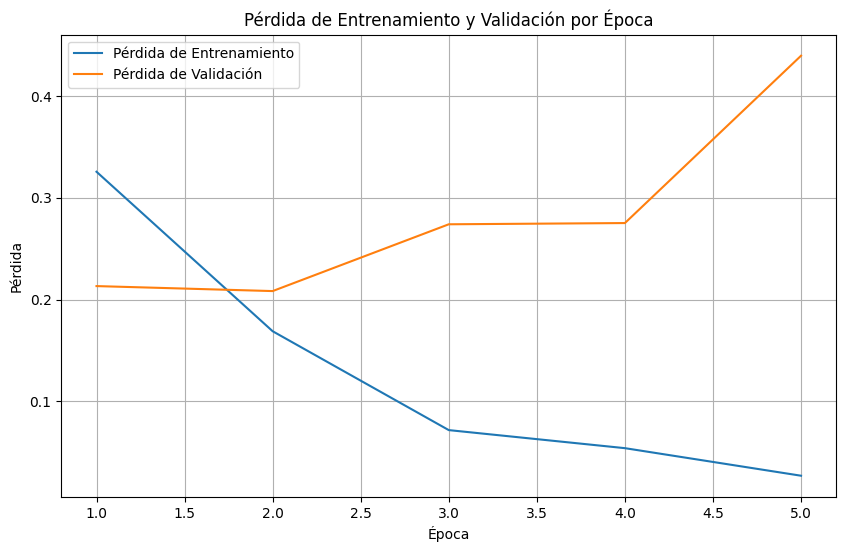

In [ ]:
# ---------------------------
# 8. Visualizar pérdidas
# ---------------------------

plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Epoch'], metrics_df['Train Loss'], label='Pérdida de Entrenamiento')
plt.plot(metrics_df['Epoch'], metrics_df['Validation Loss'], label='Pérdida de Validación')
plt.title('Pérdida de Entrenamiento y Validación por Época')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

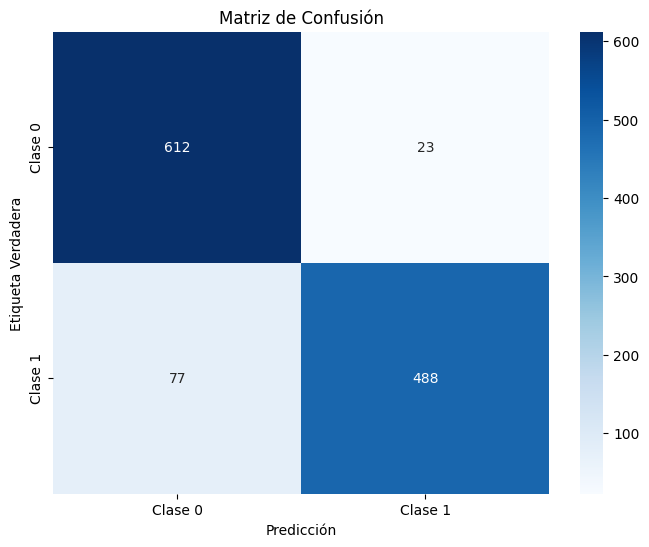

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch


# ---------------------------
# 9. Obtener predicciones del mejor modelo en el conjunto de validación
# ---------------------------

model.eval() # Poner el modelo en modo evaluación
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in val_dataloader:
        input_ids, attention_mask, features, labels = [b.to(device) for b in batch]
        outputs = model(input_ids, attention_mask, features)
        preds = torch.argmax(outputs, axis=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# ---------------------------
# 10. Generar y graficar la matriz de confusión
# ---------------------------

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'])
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Verdadera')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
#Agregar
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))



Classification Report:
              precision    recall  f1-score   support

           0     0.8882    0.9638    0.9245       635
           1     0.9550    0.8637    0.9071       565

    accuracy                         0.9167      1200
   macro avg     0.9216    0.9137    0.9158      1200
weighted avg     0.9197    0.9167    0.9163      1200



In [ ]:
!pip install textstat nltk textblob
from nltk.corpus import stopwords
import nltk
nltk.download('punkt')  # Tokenizador
nltk.download('stopwords')
nltk.download('punkt_tab')

# Descargar modelo pequeño de spaCy para español
!python -m spacy download es_core_news_sm
nltk.download('vader_lexicon')
!pip install emoji
stopwords_es = set(stopwords.words('spanish'))

In [ ]:
from transformers import AutoModel, AutoTokenizer
import torch.nn as nn

class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_extra_features):
        super().__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(bert_model.config.hidden_size + num_extra_features, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 2)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input_ids, attention_mask, extra_features):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.pooler_output
        x = torch.cat((cls_output, extra_features), dim=1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.softmax(self.fc2(x))


In [ ]:
import spacy
from transformers import BertTokenizerFast, AutoModel, pipeline
import numpy as np
import pandas as pd
from nltk.tokenize import sent_tokenize, word_tokenize
import re
import math
from collections import Counter
import textstat
import unicodedata
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import torch
import os
import emoji
import joblib
print(torch.__version__)


# 1. Configuración inicial (igual al entrenamiento)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
file_path = "/content/drive/MyDrive/Titulacion/Datasets/adverbios_conectores_satira_expandido.csv"
file_path1 = "/content/drive/MyDrive/Titulacion/Datasets/PalabrasComunes/CREA_PalabrasComunes.txt"
save_path = "/content/drive/MyDrive/Titulacion/Entrenamiento/Transfomer/bert-base-spanish/"
mode_cara = "/content/drive/MyDrive/Titulacion/Entrenamiento/Transfomer/bert-base-spanish/caracteristicas/"

model_save_path = "/content/drive/MyDrive/Titulacion/Entrenamiento/Transfomer/bert-base-spanish/caracteristicas/tokenizer_files/"
print("Contenido del directorio:", os.listdir(model_save_path))
tokenizer = BertTokenizerFast.from_pretrained(model_save_path)
vectorizer = joblib.load(mode_cara + 'tfidf_vectorizer.pkl')
scaler = joblib.load(mode_cara + 'minmax_scaler.pkl')
feature_columns = joblib.load(mode_cara + 'feature_columns.pkl')

# Usar tokenizador local
#model = torch.load(save_path + 'best_model_spanish_loss.pt', map_location=device)
df_CREA = pd.read_csv(file_path1, sep='\t', encoding='latin-1')
common_words_es = set(df_CREA["Palabra"])
model = torch.load(
    save_path + 'best_model_spanish_loss.pt',
    map_location=device,
  weights_only=False# Desactiva la protección (de confiarse en el archivo)
)
model.predict()


# Configuración inicial (ejecutar una vez)
nlp = spacy.load("es_core_news_sm")
sia = SentimentIntensityAnalyzer()

# Cargar listas de palabras (ajusta las rutas)
satirical_words = pd.read_csv(file_path, sep=';')
satirical_words = satirical_words['PALABRAS'].values.tolist()# La lista de palabras satíricas
#common_words_es = file_path1 # Lista CREA

selected_features1 = [
        'num_words', 'num_chars', 'MeanWordLen', 'LexicalDiversity',
        'DocumentLen', 'WordsPerText', 'SentencesPerText', 'MeanSentenceLen',
        'StdevSentenceLen', 'prop_NOUN', 'prop_VERB', 'prop_ADJ', 'rhetorical_questions',
        'Flesch Score', 'Lexical Entropy',
        'avg_depth', 'irony_score', 'total_satire_words', 'satire_words_density'
]
selected_features = [
    'num_words',
    'num_chars',
    'MeanWordLen',
    'LexicalDiversity',
    'DocumentLen',
    'WordsPerText',
    'SentencesPerText',
    'MeanSentenceLen',
    'StdevSentenceLen',
    'prop_NOUN',
    'prop_VERB',
    'prop_ADJ',
    'rhetorical_questions',
    'Flesch Score',
    'Lexical Entropy',
    'avg_depth',
    'irony_score',
    'Syntactic Repetition',  # Añadido (presente en el JSON)
    'Unusual Word Frequency'  # Añadido (presente en el JSON)
]
def satira(text):
    doc = nlp(text)
    text = text.lower()

    # Normalizar y limpiar el texto (quitar acentos y puntuación)
    text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    text = ''.join(c for c in text if c not in '"#$%&\'()*+-/:<=>@[\\]^_`{|}~')

    satire_words_count = {}
    total_satire_words = 0
    for phrase in satirical_words:  # <- Lista cargada desde CSV
        satire_words_count[phrase] = text.count(phrase.lower())
        total_satire_words += satire_words_count[phrase]

    word_count = len([token.text for token in doc if not token.is_punct])
    satire_words_density = total_satire_words / word_count if word_count else 0

    return {
        **satire_words_count,
        "total_satire_words": total_satire_words,
        "satire_words_density": satire_words_density
    }
def calculate_dependency_metrics(text):
    doc = nlp(text)
    total_depth = 0
    sentence_count = 0

    for sent in doc.sents:
        depths = [token.head.i - token.i if token.head != token else 0 for token in sent]
        total_depth += max(depths) if depths else 0
        sentence_count += 1

    avg_depth = total_depth / sentence_count if sentence_count else 0
    return {"avg_depth": avg_depth}
def flesch_score(text, lang="es"):
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]

    if not sentences:
        return None

    num_sentences = len(sentences)
    num_words = sum(len(s.split()) for s in sentences)
    num_syllables = sum(textstat.syllable_count(word) for word in text.split())

    asl = num_words / num_sentences  # Longitud media de las frases
    asw = num_syllables / num_words  # Promedio de sílabas por palabra

    score = 206.84 - (1.02 * asl) - (60 * asw)  # Fórmula para español
    return round(score, 2)
def lexical_entropy(text):
    words = text.lower().split()
    word_counts = Counter(words)
    total_words = sum(word_counts.values())

    entropy = -sum((count / total_words) * math.log2(count / total_words)
              for count in word_counts.values())
    return round(entropy, 2)
def syntactic_pattern_repetition(text):
    doc = nlp(text)
    dep_patterns = [token.dep_ for token in doc]  # Ej: ['nsubj', 'ROOT', 'dobj']
    dep_counts = Counter(dep_patterns)

    repetition_index = max(dep_counts.values()) / len(dep_patterns) if dep_patterns else 0
    return round(repetition_index, 2)


def unusual_word_frequency(text):
    words_in_text = set(word.lower() for word in text.split())
    common_set = common_words_es  # <- Set cargado desde CREA_PalabrasComunes.txt
    unusual_words = words_in_text - common_set
    return round(len(unusual_words) / len(words_in_text), 2) if words_in_text else 0
def analyze_text(text):
    return {
        "Flesch Score": flesch_score(text),  # Usae textstat.flesch_reading_ease()
        "Lexical Entropy": lexical_entropy(text),  # Basado en Counter() y math.log2
        "Syntactic Repetition": syntactic_pattern_repetition(text),  # Conteo de dependencias
        "Unusual Word Frequency": unusual_word_frequency(text)  # Compara con common_words_es
    }
def preprocess_text(text):
    # 1️⃣ Convertir a minúsculas
    text = text.lower()

    # 2️⃣ Eliminar URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)

    # 3️⃣ Eliminar emojis
    text = emoji.replace_emoji(text, replace="")

    #texto = re.sub(r'[\U00010000-\U0010ffff]', '', text)  # Eliminar emogis
    text = re.sub(r'@\w+', '', text) # Eliminar menciones de usuario (@usuario)
    text = re.sub(r'#\w+', '', text)  # Eliminar hashtags
    #texto = re.sub(r'\b(?:https?://|www\.)\S+\b', '', text)  # Eliminar enlaces
    text = re.sub(r'\d+', '', text) # Eliminar números
    text = re.sub(r'\s+', ' ', text).strip() # Eliminar espacios en blanco extra

    # 4️⃣ Eliminar caracteres especiales (manteniendo puntuación relevante)
    text = re.sub(r"[^a-zA-Záéíóúüñ¿?¡!.,;]", " ", text)

    # 6️⃣ Tokenización y lematización con spaCy
    doc = nlp(text)
    text = " ".join([token.lemma_ for token in doc if token.text not in stopwords_es])
    #text = " ".join([token.lemma_ for token in doc if token.is_alpha and (token.text in satirical_words or token.text.lower() not in stopwords_es)])

    return text

# ---- Funciones auxiliares copiadas del script ----
def calculate_avg_depth(text):
    doc = nlp(text)
    total_depth = 0
    for sent in doc.sents:
        depths = [abs(token.head.i - token.i) for token in sent]
        total_depth += max(depths) if depths else 0
    return total_depth / len(list(doc.sents)) if doc.sents else 0

irony_detector = pipeline("text-classification", model="cardiffnlp/twitter-roberta-base-irony")
def calculate_features(text):
    """Replica exactamente tus funciones originales de extracción de características"""
    doc = nlp(text)
    num_words = len(word_tokenize(text))

    # 1. Características básicas (del JSON)
    tokens = text.split()

    sentences = [s.strip() for s in text.split('.') if s.strip()]

    # Llamada a todas las funciones auxiliares
    satire_features = satira(text)
    dependency_metrics = calculate_dependency_metrics(text)
    text_analysis = analyze_text(text)
    features = {

        # 1. Métricas básicas de texto
        'num_words': len(tokens),
        'num_chars': len(text),
        'MeanWordLen': np.mean([len(w) for w in tokens]) if tokens else 0,
        'LexicalDiversity': (len(set(tokens)) / len(tokens)) * 100 if tokens else 0,
        'DocumentLen': len(text),
        'WordsPerText': len(tokens),

        # 2. Métricas de oraciones
        'SentencesPerText': len(sentences),
        'MeanSentenceLen': np.mean([len(s.split()) for s in sentences]) if sentences else 0,
        'StdevSentenceLen': np.std([len(s.split()) for s in sentences]) if sentences else 0,

        # 3. POS tagging y estructura sintáctica
        'prop_NOUN': sum(1 for token in doc if token.pos_ == "NOUN") / num_words if num_words else 0,
        'prop_VERB': sum(1 for token in doc if token.pos_ == "VERB") / num_words if num_words else 0,
        'prop_ADJ': sum(1 for token in doc if token.pos_ == "ADJ") / num_words if num_words else 0,
        'rhetorical_questions': sum(1 for sent in doc.sents if '?' in sent.text),
        'avg_depth': dependency_metrics['avg_depth'],

        # 4. Legibilidad y complejidad
        'Flesch Score': text_analysis['Flesch Score'],
        'Lexical Entropy': text_analysis['Lexical Entropy'],
        'Syntactic Repetition': text_analysis['Syntactic Repetition'],
        'Unusual Word Frequency': text_analysis['Unusual Word Frequency'],

        # 5. Ironía y sátira
        'irony_score': irony_detector(text)[0]['score'],
        'total_satire_words': satire_features['total_satire_words'],
        'satire_words_density': satire_features['satire_words_density'],

        # 6. Otras características de las funciones
        'exclamations': text.count("!"),
        'uppercase_ratio': sum(1 for c in text if c.isupper()) / max(1, len(text)),
        'polarity': TextBlob(text).sentiment.polarity,
        'subjectivity': TextBlob(text).sentiment.subjectivity,
        'Polaridad_VADER': sia.polarity_scores(text)['compound'],
        'prop_ADV': sum(1 for token in doc if token.pos_ == "ADV") / len(doc) if doc else 0,
        'metaphors': len(re.findall(r'\bcomo\b|\bes como\b', text, re.IGNORECASE))
    }

    return {k: features[k] for k in selected_features}  # Solo devuelve las features usadas

def predict_satire(text):
    # 1. Preprocesar texto para TF-IDF (string)
    processed_text = preprocess_text(text)  # <- Debe ser string, no dict

    # 2. Tokenización para BERT
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)

    # 3. Obtener embeddings de BERTEs
    with torch.no_grad():
        outputs = model.bert(**inputs)
        cls_output = outputs.last_hidden_state[:, 0, :]  # [1, 768]

    # 4. Features de TF-IDF (3000 dim)
    tfidf_features = vectorizer.transform([processed_text]).toarray()  # Usar processed_text (string)
    tfidf_tensor = torch.tensor(tfidf_features, dtype=torch.float32).to(device)

    # 5. Features adicionales (19 dim)
    features_dict = calculate_features(text)  # Devuelve dict
    features_values = [features_dict[k] for k in selected_features]  # Orden correcto

    # 6. Combinar features (3000 TF-IDF + 19 adicionales = 3019)
    combined_features_np = np.concatenate([tfidf_features, np.array([features_values])], axis=1)  # [1, 3019]

    # 7. Aplicar scaler (CRÍTICO)
    combined_features_normalized = scaler.transform(combined_features_np)  # Normalización
    combined_features = torch.tensor(combined_features_normalized, dtype=torch.float32).to(device)

    # features_tensor = torch.tensor([features_values], dtype=torch.float32).to(device)

    # 6. Combinar features (3000 + 19 = 3020)
    #combined_features = torch.cat((tfidf_tensor, features_tensor), dim=1)
    #combined_features_normalized = scaler.transform(combined_features)
    # 7. Verificar dimensiones (DEBUG)
    print(f"CLS shape: {cls_output.shape}")  # [1, 768]
    print(f"Features shape: {combined_features.shape}")  # [1, 3019]

    # 8. Concatenar con BERT y predecir
    combined = torch.cat((cls_output, combined_features), dim=1)
    x = model.dropout(model.relu(model.fc1(combined)))
    output = model.softmax(model.fc2(x))

    # 9. Obtener probabilidad y clasificación
    prob_satira = torch.exp(output)[0][1].item()  # Probabilidad de ser sátira
    prediction = "ES SÁTIRA" if prob_satira >= 0.5 else "NO es sátira"

    return prob_satira, prediction# Probabilidad de clase 1




In [ ]:
texto_ejemplo = "me gusta despertarme temprano en la mañana"
probabilidad, resultado = predict_satire(texto_ejemplo)

print(f"Probabilidad de ser sátira: {probabilidad:.2%}")
print(f"Resultado: {resultado}")